In [1]:
%matplotlib inline
import os, warnings
import numpy as np
import pandas as pd
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import rcParams

warnings.filterwarnings('ignore')

rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        8,
    'axes.titlesize':   8,
    'axes.labelsize':   8,
    'xtick.labelsize':  7,
    'ytick.labelsize':  7,
    'legend.fontsize':  7,
    'lines.linewidth':  1.0,
    'axes.linewidth':   0.6,
    'xtick.major.width':0.6,
    'ytick.major.width':0.6,
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
})

W1 = 3.46
W2 = 7.09
DPI = 300

ROOT    = os.path.abspath('.')
FIG_DIR = os.path.join(ROOT, 'figures', 'output')
DAT_DIR = os.path.join(ROOT, 'figures', 'csv')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DAT_DIR, exist_ok=True)

def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name + '.pdf'), bbox_inches='tight', dpi=DPI)
    fig.savefig(os.path.join(FIG_DIR, name + '.png'), bbox_inches='tight', dpi=DPI)
    plt.show()
    plt.close('all')
    print(f'  ✓ {name}  →  figures/output/')

# Algorithm display order: PCA flagship first, then specialists, marginal, then baselines
ALG_ORDER = ['P-Hybrid', 'P-Motion_Adaptive', 'P-SpatialTemporal',
             'PatchAvg_Bandpass', 'P-CodecRobust', 'Raw_POS', '2SR']

VARIANT_ORDER = [
    'none','yuv420_chroma','jpeg_q50','jpeg_q30',
    'h264_intra','h264_gop15','h265_intra','h265_gop15',
    'mpeg4_low','mpeg4_med','mpeg4_500k',
]
VARIANT_LABELS = [
    'none','YUV420','JPEG q50','JPEG q30',
    'H264 intra','H264 GOP15','H265 intra','H265 GOP15',
    'MPEG4 85k','MPEG4 200k','MPEG4 500k',
]
CAMERA_LABELS = {
    'FullHDwebcam': 'FullHD-cam (1346 kbps)',
    'IriunWebcam':  'Iriun-cam (792 kbps)',
    'USBVideo':     'USB-cam (1567 kbps)',
}
FAM_COLORS = {
    'Clean':  '#4878CF',
    'JPEG':   '#6ACC65',
    'H.264':  '#D65F5F',
    'H.265':  '#B47CC7',
    'MPEG-4': '#C4AD66',
    'YUV':    '#a6cee3',
}
ALGO_STYLES = {
    'P-Hybrid':          {'color': '#33a02c', 'ls': '-',  'marker': '^', 'lw': 1.8},
    'P-Motion_Adaptive': {'color': '#ff7f00', 'ls': '-',  'marker': 's', 'lw': 1.5},
    'P-SpatialTemporal': {'color': '#e31a1c', 'ls': '-',  'marker': 'o', 'lw': 1.5},
    'PatchAvg_Bandpass': {'color': '#6a3d9a', 'ls': '--', 'marker': 'D', 'lw': 1.2},
    'P-CodecRobust':     {'color': '#b15928', 'ls': '--', 'marker': 'v', 'lw': 1.0},
    'Raw_POS':           {'color': '#1f78b4', 'ls': ':',  'marker': 'p', 'lw': 1.0},
    '2SR':               {'color': '#a6cee3', 'ls': ':',  'marker': '*', 'lw': 1.0},
}

print('Setup OK — outputs → figures/output/ | data → figures/csv/')

Setup OK — outputs → figures/output/ | data → figures/csv/


## Fig 01 — SAC scatter: per-cell SAC vs PCA advantage

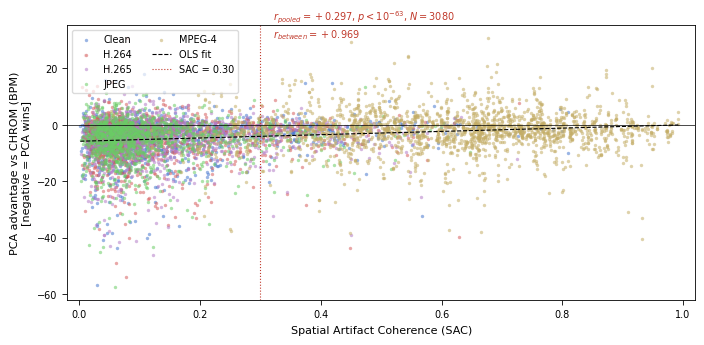

  ✓ fig01_sac_scatter  →  figures/output/


In [2]:
df = pd.read_csv(os.path.join(DAT_DIR, 'fig01_sac_scatter_data.csv'))
df = df.dropna(subset=['SAC','delta'])

fig, ax = plt.subplots(figsize=(W2, 3.5))

for fam, grp in df.groupby('family'):
    ax.scatter(grp['SAC'], grp['delta'],
               c=FAM_COLORS.get(fam, '#888888'),
               label=fam, s=6, alpha=0.55, linewidths=0)

# regression line (NaNs already dropped above)
dfc = df
slope, intercept, r_val, p_val, _ = sp_stats.linregress(dfc['SAC'], dfc['delta'])
xs = np.linspace(dfc['SAC'].min(), dfc['SAC'].max(), 200)
ax.plot(xs, slope*xs + intercept, 'k--', lw=0.8, label='OLS fit')

ax.axvline(0.30, color='#C0392B', lw=0.8, ls=':', label='SAC = 0.30')
ax.axhline(0,    color='k',       lw=0.5, ls='-')

ax.set_xlabel('Spatial Artifact Coherence (SAC)')
ax.set_ylabel('PCA advantage vs CHROM (BPM)\n[negative = PCA wins]')
ax.text(0.32, ax.get_ylim()[1]*0.88,
        r'$r_{pooled} = +0.297$, $p < 10^{-63}$, $N = 3080$' + '\n' + r'$r_{between} = +0.969$',
        fontsize=7, color='#C0392B')
ax.legend(loc='upper left', ncol=2, framealpha=0.7)
ax.set_xlim(-0.02, 1.02)

fig.tight_layout()
savefig(fig, 'fig01_sac_scatter')


## Fig 02 — H1: off-diagonal SAC ratio by variant and dataset

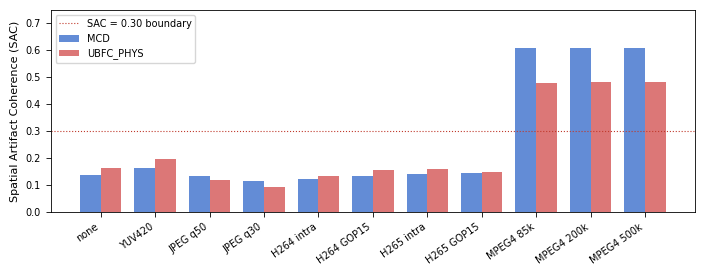

  ✓ fig02_h1_sac_ratio  →  figures/output/


In [3]:
df = pd.read_csv(os.path.join(DAT_DIR, 'fig02_h1_offdiag_data.csv'))

datasets   = df['dataset'].unique()
variants   = df['variant'].tolist()

# pivot so rows=dataset, cols=variant
piv = df.pivot(index='dataset', columns='variant', values='SAC_ratio')

# pick variants present in the data
v_order = [v for v in VARIANT_ORDER if v in piv.columns]
v_labels = [VARIANT_LABELS[VARIANT_ORDER.index(v)] for v in v_order]
piv = piv[v_order]

ds_colors = {'MCD': '#4878CF', 'UBFC_PHYS': '#D65F5F'}

n_ds  = len(piv.index)
n_var = len(v_order)
x     = np.arange(n_var)
width = 0.38

fig, ax = plt.subplots(figsize=(W2, 2.8))
for i, ds in enumerate(piv.index):
    offset = (i - (n_ds - 1) / 2) * width
    bars = ax.bar(x + offset, piv.loc[ds].values,
                  width=width, label=ds,
                  color=ds_colors.get(ds, '#888888'), alpha=0.85)

ax.axhline(0.30, color='#C0392B', lw=0.8, ls=':', label='SAC = 0.30 boundary')
ax.set_xticks(x)
ax.set_xticklabels(v_labels, rotation=35, ha='right')
ax.set_ylabel('Spatial Artifact Coherence (SAC)')
ax.legend()
ax.set_ylim(0, 0.75)

fig.tight_layout()
savefig(fig, 'fig02_h1_sac_ratio')


## Baseline enrichment — inject Raw_POS (Wang 2017) and 2SR into figure CSVs

Reads evaluation CSV folders directly and appends Raw_POS and 2SR rows to
fig03, fig05, fig08 data CSVs so they appear in all comparison figures.

In [4]:
import os, glob, sys

# ── get EVAL_ROOT from pipeline_config (has the correct E: drive path) ───────
sys.path.insert(0, ROOT)
from pipeline_config import EVAL_ROOT, DSP
FPS_STR = f"{int(DSP['target_fps'])}Hz"
BASELINE_ALGS = ['Raw_POS', '2SR']
CHROM_ALG     = 'CHROM__T_CWT'

VARIANT_ORDER_ALL = [
    'none','yuv420_chroma','jpeg_q50','jpeg_q30',
    'h264_intra','h264_gop15','h265_intra','h265_gop15',
    'mpeg4_low','mpeg4_med','mpeg4_500k',
]

def load_alg_mae(dataset, alg, camera_filter=None):
    """Mean MAE per variant, reading evaluation CSVs directly."""
    records = []
    for variant in VARIANT_ORDER_ALL:
        csv_dir = os.path.join(EVAL_ROOT, dataset, FPS_STR, variant, alg, 'csv')
        if not os.path.isdir(csv_dir):
            continue
        for fname in os.listdir(csv_dir):
            if not fname.endswith('.csv'):
                continue
            try:
                tmp = pd.read_csv(os.path.join(csv_dir, fname), low_memory=False)
                if camera_filter and 'camera' in tmp.columns:
                    tmp = tmp[tmp['camera'].isin(camera_filter)]
                if tmp.empty:
                    continue
                mae_col = next((c for c in ['MAE','mae','mae_bpm'] if c in tmp.columns), None)
                if mae_col is None:
                    continue
                if 'face_detected' in tmp.columns:
                    tmp = tmp[tmp['face_detected'] == 1]
                records.append({'variant': variant, 'MAE': tmp[mae_col].mean()})
            except Exception:
                pass
    if not records:
        return pd.Series(dtype=float, name=alg)
    return pd.DataFrame(records).groupby('variant')['MAE'].mean().reindex(VARIANT_ORDER_ALL)

if not os.path.isdir(EVAL_ROOT):
    print(f'Evaluation folder not found: {EVAL_ROOT} — Raw_POS/2SR will be absent.')
else:
    print(f'Enriching figure CSVs from {EVAL_ROOT} ...')
    tasks = [
        (os.path.join(DAT_DIR, 'fig03_heatmap_mcd.csv'),       'MCD',       None,            'delta'),
        (os.path.join(DAT_DIR, 'fig03_heatmap_ubfc_phys.csv'), 'UBFC_PHYS', None,            'delta'),
        (os.path.join(DAT_DIR, 'fig03_heatmap_ubfc_rppg.csv'), 'UBFC_rPPG', None,            'delta'),
        (os.path.join(DAT_DIR, 'fig05_algorithm_profiles_mcd.csv'), 'MCD',  None,            'abs'),
        (os.path.join(DAT_DIR, 'fig08_iriun_deep_dive.csv'),   'MCD',       ['IriunWebcam'], 'abs'),
    ]
    chrom_cache = {}
    for csv_path, dataset, cam_filter, kind in tasks:
        tbl = pd.read_csv(csv_path, index_col=0)
        if kind == 'delta':
            key = (dataset, tuple(cam_filter) if cam_filter else None)
            if key not in chrom_cache:
                chrom_cache[key] = load_alg_mae(dataset, CHROM_ALG, cam_filter)
            chrom_mae = chrom_cache[key]
        changed = False
        for label in BASELINE_ALGS:
            mae = load_alg_mae(dataset, label, cam_filter)
            if mae.isna().all():
                print(f'  WARN: {label}/{dataset} — no CSVs found, skipping')
                continue
            row = (mae - chrom_mae if kind == 'delta' else mae).reindex(tbl.columns)
            tbl.loc[label] = row.values
            changed = True
            print(f'  {label} -> {os.path.basename(csv_path)}  MAE range [{mae.min():.1f}, {mae.max():.1f}] BPM')
        if changed:
            tbl.to_csv(csv_path)
    print('Baseline enrichment complete.')


Enriching figure CSVs from E:\Projects_Results\TBME_PATCH_PCA_CODEC\evaluation ...
  Raw_POS -> fig03_heatmap_mcd.csv  MAE range [19.2, 23.2] BPM
  2SR -> fig03_heatmap_mcd.csv  MAE range [28.5, 29.4] BPM
  Raw_POS -> fig03_heatmap_ubfc_phys.csv  MAE range [16.6, 20.5] BPM
  2SR -> fig03_heatmap_ubfc_phys.csv  MAE range [25.0, 25.0] BPM
  Raw_POS -> fig03_heatmap_ubfc_rppg.csv  MAE range [22.5, 34.7] BPM
  2SR -> fig03_heatmap_ubfc_rppg.csv  MAE range [42.6, 42.6] BPM
  Raw_POS -> fig05_algorithm_profiles_mcd.csv  MAE range [19.2, 23.2] BPM
  2SR -> fig05_algorithm_profiles_mcd.csv  MAE range [28.5, 29.4] BPM
  Raw_POS -> fig08_iriun_deep_dive.csv  MAE range [22.2, 29.0] BPM
  2SR -> fig08_iriun_deep_dive.csv  MAE range [34.8, 35.8] BPM
Baseline enrichment complete.


## Fig 03 — Delta-MAE heatmap: all algorithms × variant (3 datasets)

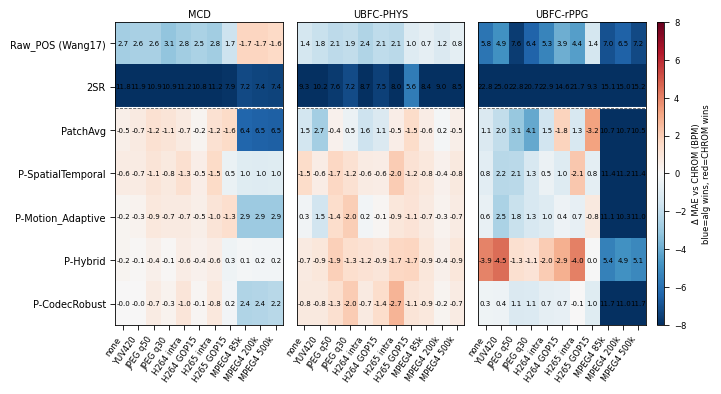

  ✓ fig03_mae_heatmap  →  figures/output/


In [5]:
M_mcd  = pd.read_csv(os.path.join(DAT_DIR, 'fig03_heatmap_mcd.csv'),  index_col=0)
M_phys = pd.read_csv(os.path.join(DAT_DIR, 'fig03_heatmap_ubfc_phys.csv'), index_col=0)
M_rppg = pd.read_csv(os.path.join(DAT_DIR, 'fig03_heatmap_ubfc_rppg.csv'), index_col=0)

# Row ordering: baselines first, then PatchPCA family
BASELINE_ROWS = ['Raw_POS', '2SR']
PCA_ROWS      = ['PatchAvg_Bandpass','P-SpatialTemporal','P-Motion_Adaptive','P-Hybrid','P-CodecRobust']

algo_labels = {
    'PatchAvg_Bandpass':  'PatchAvg',
    'P-SpatialTemporal':  'P-SpatialTemporal',
    'P-Motion_Adaptive':  'P-Motion_Adaptive',
    'P-Hybrid':           'P-Hybrid',
    'P-CodecRobust':      'P-CodecRobust',
    'Raw_POS':            'Raw_POS (Wang17)',
    '2SR':                '2SR',
}
title_map = {
    'mcd':       'MCD',
    'ubfc_phys': 'UBFC-PHYS',
    'ubfc_rppg': 'UBFC-rPPG',
}

def ordered_rows(m):
    present_base = [r for r in BASELINE_ROWS if r in m.index]
    present_pca  = [r for r in PCA_ROWS      if r in m.index]
    other = [r for r in m.index if r not in BASELINE_ROWS + PCA_ROWS]
    return present_base + present_pca + other

max_rows = max(len(ordered_rows(M_mcd)), len(ordered_rows(M_phys)), len(ordered_rows(M_rppg)))
fig_h = max(2.8, 0.42 * max_rows + 1.0)

fig, axes = plt.subplots(1, 3, figsize=(W2, fig_h),
                         gridspec_kw={'wspace': 0.08})

cmap = 'RdBu_r'
vlim = 8

# Note: delta = algorithm_MAE - CHROM_MAE. Negative = algorithm wins.
# We flip sign for display so that blue = algorithm wins.

for ax, (m, ds) in zip(axes, [(M_mcd,'mcd'), (M_phys,'ubfc_phys'), (M_rppg,'ubfc_rppg')]):
    v_order_here = [v for v in VARIANT_ORDER if v in m.columns]
    rows = ordered_rows(m)
    m_plot = m.loc[rows, v_order_here]
    row_names = [algo_labels.get(r, r) for r in rows]

    im = ax.imshow(-m_plot.values, cmap=cmap, vmin=-vlim, vmax=vlim,
                   aspect='auto')

    ax.set_xticks(range(len(v_order_here)))
    ax.set_xticklabels(
        [VARIANT_LABELS[VARIANT_ORDER.index(v)] for v in v_order_here],
        rotation=55, ha='right', fontsize=6)

    if ax is axes[0]:
        ax.set_yticks(range(len(row_names)))
        ax.set_yticklabels(row_names, fontsize=7)
    else:
        ax.set_yticks([])

    ax.set_title(title_map[ds], fontsize=7, pad=3)

    # separator between baseline rows and PCA rows
    n_base = len([r for r in BASELINE_ROWS if r in m.index])
    if 0 < n_base < len(rows):
        ax.axhline(n_base - 0.5, color='white', lw=1.5)
        ax.axhline(n_base - 0.5, color='#555555', lw=0.6, ls='--')

    for i in range(m_plot.shape[0]):
        for j in range(m_plot.shape[1]):
            val = m_plot.values[i, j]
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=5, color='k')

cbar = fig.colorbar(im, ax=axes, orientation='vertical',
                    fraction=0.015, pad=0.02, aspect=40)
cbar.set_label('Δ MAE vs CHROM (BPM)\nblue=alg wins, red=CHROM wins', fontsize=6)
cbar.ax.tick_params(labelsize=6)

fig.tight_layout(rect=[0, 0, 0.93, 1])
savefig(fig, 'fig03_mae_heatmap')


## Fig 04 — H3: ΔMAE vs CHROM — H.265 intra → GOP15 transition (per camera)

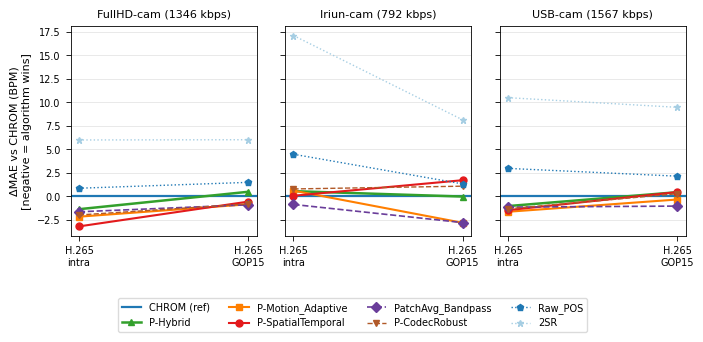

  ✓ fig04_h3_interaction  →  figures/output/


In [6]:
df = pd.read_csv(os.path.join(DAT_DIR, 'fig04_h3_interaction_data.csv'))
cameras   = df['camera'].unique().tolist()
alg_order = [a for a in ALG_ORDER if a in df['algorithm'].values]
alg_order += [a for a in df['algorithm'].unique() if a not in alg_order and a != 'CHROM']
palette   = plt.cm.tab10(np.linspace(0, 1, len(alg_order)))
fig, axes = plt.subplots(1, len(cameras), figsize=(W2, 3.2), sharey=True)
if len(cameras) == 1: axes = [axes]
for ax, cam in zip(axes, cameras):
    sub = df[df['camera'] == cam].set_index('algorithm')[['h265_intra', 'h265_gop15']]
    chrom_intra = sub.loc['CHROM', 'h265_intra']
    chrom_gop15 = sub.loc['CHROM', 'h265_gop15']
    ax.axhline(0, color='#1f78b4', lw=1.6, ls='-', label='CHROM (ref)', zorder=2)
    for alg, col in zip(alg_order, palette):
        if alg not in sub.index: continue
        style = ALGO_STYLES.get(alg, {})
        ax.plot(['H.265\nintra', 'H.265\nGOP15'],
                [sub.loc[alg,'h265_intra']-chrom_intra, sub.loc[alg,'h265_gop15']-chrom_gop15],
                marker=style.get('marker','o'), ms=5, lw=style.get('lw',1.2),
                color=style.get('color',col), ls=style.get('ls','-'), label=alg)
    ax.set_title(CAMERA_LABELS.get(cam, cam), fontsize=8)
    if ax is axes[0]: ax.set_ylabel('ΔMAE vs CHROM (BPM)\n[negative = algorithm wins]')
    ax.grid(axis='y', lw=0.4, alpha=0.5)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=7,
           bbox_to_anchor=(0.5, -0.06), framealpha=0.7)
fig.tight_layout(rect=[0, 0.12, 1, 1])
savefig(fig, 'fig04_h3_interaction')

## Fig 05 — Algorithm profiles on MCD: ΔMAE vs CHROM across 11 variants

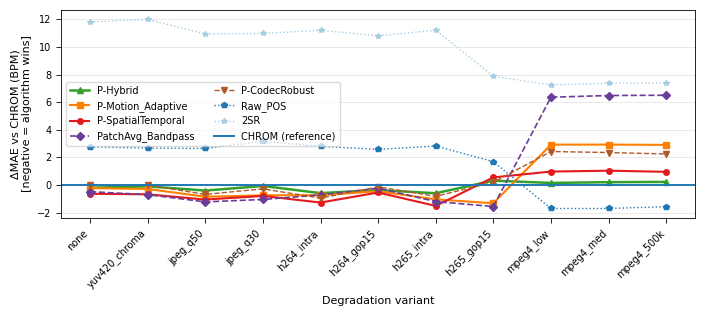

  ✓ fig05_algorithm_profiles_mcd  →  figures/output/


In [7]:
df = pd.read_csv(os.path.join(DAT_DIR, 'fig05_algorithm_profiles_mcd.csv'), index_col=0)
chrom_row = df.loc['CHROM']
df_delta  = df.drop(index='CHROM').apply(lambda row: row - chrom_row, axis=1)
variants  = df_delta.columns.tolist()
x         = np.arange(len(variants))
alg_order = [a for a in ALG_ORDER if a in df_delta.index]
alg_order += [a for a in df_delta.index if a not in alg_order]
palette   = plt.cm.tab10(np.linspace(0, 1, len(alg_order)))
fig, ax = plt.subplots(figsize=(W2, 3.2))
for alg, col in zip(alg_order, palette):
    style = ALGO_STYLES.get(alg, {})
    ax.plot(x, df_delta.loc[alg].values, marker=style.get('marker','o'), ms=4,
            lw=style.get('lw',1.2), color=style.get('color',col), ls=style.get('ls','-'), label=alg)
ax.axhline(0, color='#1f78b4', lw=1.4, ls='-', label='CHROM (reference)', zorder=2)
ax.set_xticks(x); ax.set_xticklabels(variants, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('ΔMAE vs CHROM (BPM)\n[negative = algorithm wins]')
ax.set_xlabel('Degradation variant')
ax.legend(fontsize=7, ncol=2, framealpha=0.7)
ax.grid(axis='y', lw=0.4, alpha=0.5)
fig.tight_layout()
savefig(fig, 'fig05_algorithm_profiles_mcd')

## Fig 06 — Source state contrast: P-Hybrid − CHROM delta on UBFC-rPPG vs MCD

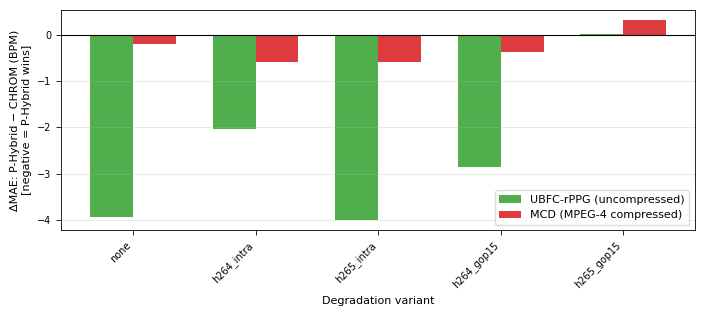

  ✓ fig06_source_state_contrast  →  figures/output/


In [8]:
df = pd.read_csv(os.path.join(DAT_DIR, 'fig06_source_state_contrast.csv'))
v_order = ['none','h264_intra','h265_intra','h264_gop15','h265_gop15',
           'h264_gop30','h265_gop30','blur_mild','blur_heavy','noise_mild','noise_heavy']
v_order = [v for v in v_order if v in df['variant'].values]
df = df.set_index('variant').reindex(v_order).reset_index()
df['delta_rPPG'] = df['P-Hybrid_rPPG'] - df['CHROM_rPPG']
df['delta_MCD']  = df['P-Hybrid_MCD']  - df['CHROM_MCD']
x = np.arange(len(df)); width = 0.35
fig, ax = plt.subplots(figsize=(W2, 3.2))
ax.bar(x-width/2, df['delta_rPPG'].values, width, label='UBFC-rPPG (uncompressed)', color='#33a02c', alpha=0.85)
ax.bar(x+width/2, df['delta_MCD'].values,  width, label='MCD (MPEG-4 compressed)',  color='#d7191c', alpha=0.85)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(df['variant'].values, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('ΔMAE: P-Hybrid − CHROM (BPM)\n[negative = P-Hybrid wins]')
ax.set_xlabel('Degradation variant')
ax.legend(fontsize=8, framealpha=0.7); ax.grid(axis='y', lw=0.4, alpha=0.5)
fig.tight_layout()
savefig(fig, 'fig06_source_state_contrast')

## Fig 07 — PPG waveform: best-case P-Hybrid vs CHROM vs GT (UBFC-rPPG, none)

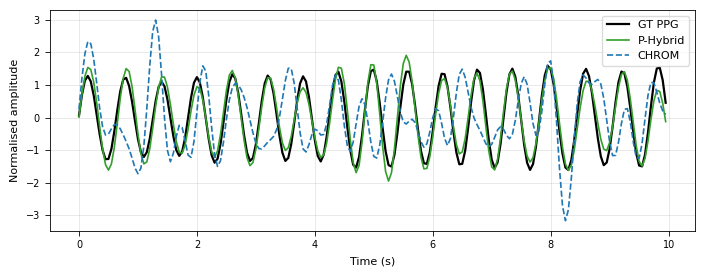

  ✓ fig07_waveform_best_case  →  figures/output/


In [9]:
df = pd.read_csv(os.path.join(DAT_DIR, 'fig07_waveform_best_case.csv'))
best = df[(df['algo']=='P-Hybrid') & (df['variant']=='none') & (df['rank']==1)]
best_subj = best.sort_values('r_pca', ascending=False)['subject_id'].iloc[0]
seg = best[best['subject_id']==best_subj].sort_values('time_s')
t = seg['time_s'].values
def znorm(x): return (x - x.mean()) / (x.std() + 1e-9)
gt = znorm(seg['gt_ppg'].values)
ph = znorm(seg['rppg_pca'].values)
ch = znorm(seg['rppg_chrom'].values)
fig, ax = plt.subplots(figsize=(W2, 2.8))
ax.plot(t, gt, lw=1.6, color='k',       label='GT PPG')
ax.plot(t, ph, lw=1.2, color='#33a02c', ls='-',  label='P-Hybrid')
ax.plot(t, ch, lw=1.2, color='#1f78b4', ls='--', label='CHROM')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Normalised amplitude')
ax.legend(fontsize=8, framealpha=0.7); ax.grid(lw=0.4, alpha=0.5)
fig.tight_layout()
savefig(fig, 'fig07_waveform_best_case')

## Fig 08 — IriunWebcam deep dive: ΔMAE vs CHROM, all 11 variants

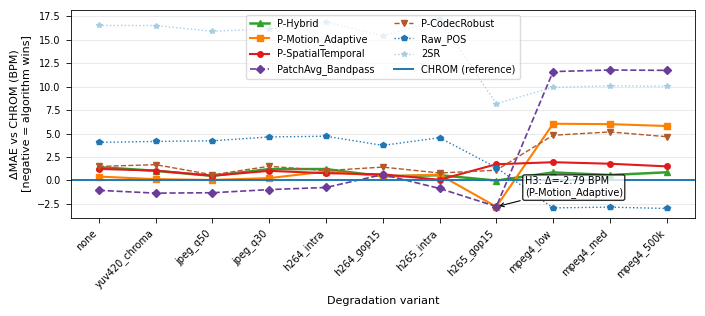

  ✓ fig08_iriun_deep_dive  →  figures/output/


In [10]:
df = pd.read_csv(os.path.join(DAT_DIR, 'fig08_iriun_deep_dive.csv'), index_col=0)
chrom_row = df.loc['CHROM']
df_delta  = df.drop(index='CHROM').apply(lambda row: row - chrom_row, axis=1)
variants  = df_delta.columns.tolist()
x         = np.arange(len(variants))
alg_order = [a for a in ALG_ORDER if a in df_delta.index]
alg_order += [a for a in df_delta.index if a not in alg_order]
palette   = plt.cm.tab10(np.linspace(0, 1, len(alg_order)))
fig, ax = plt.subplots(figsize=(W2, 3.2))
for alg, col in zip(alg_order, palette):
    style = ALGO_STYLES.get(alg, {})
    ax.plot(x, df_delta.loc[alg].values, marker=style.get('marker','o'), ms=4,
            lw=style.get('lw',1.2), color=style.get('color',col), ls=style.get('ls','-'), label=alg)
ax.axhline(0, color='#1f78b4', lw=1.4, ls='-', label='CHROM (reference)', zorder=2)
if 'P-Motion_Adaptive' in df_delta.index and 'h265_gop15' in df_delta.columns:
    gop_idx = list(variants).index('h265_gop15')
    d = df_delta.loc['P-Motion_Adaptive', 'h265_gop15']
    ax.annotate(f'H3: Δ={d:+.2f} BPM\n(P-Motion_Adaptive)',
                xy=(gop_idx, d), xytext=(gop_idx+0.5, d+1.2), fontsize=7,
                arrowprops=dict(arrowstyle='->', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
ax.set_xticks(x); ax.set_xticklabels(variants, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('ΔMAE vs CHROM (BPM)\n[negative = algorithm wins]')
ax.set_xlabel('Degradation variant')
ax.legend(fontsize=7, ncol=2, framealpha=0.7)
ax.grid(axis='y', lw=0.4, alpha=0.5)
fig.tight_layout()
savefig(fig, 'fig08_iriun_deep_dive')

## Fig S2 — PPG signal fidelity: Pearson r (rPPG vs GT) across variants — UBFC-rPPG

Source: `results/ppg_correlation_results.csv`  
Panel A: P-Hybrid vs CHROM absolute mean_r across 11 variants.  
Panel B: delta_r heatmap (3 PCA algos × 11 variants). Stars = significance vs CHROM.

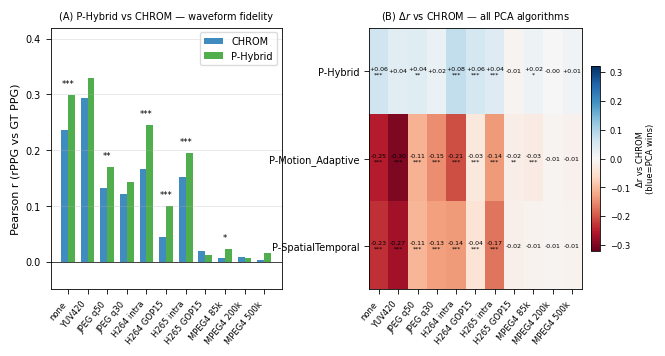

  ✓ figS2_ppg_corr_ubfc  →  figures/output/
P-Hybrid wins (delta_r > 0, UBFC-rPPG):
  none                  delta_r=+0.063  ***
  yuv420_chroma         delta_r=+0.036  ns
  jpeg_q50              delta_r=+0.038  **
  jpeg_q30              delta_r=+0.021  ns
  h264_intra            delta_r=+0.078  ***
  h264_gop15            delta_r=+0.055  ***
  h265_intra            delta_r=+0.042  ***
  mpeg4_low             delta_r=+0.015  *
  mpeg4_500k            delta_r=+0.012  ns


In [11]:
import matplotlib.patches as mpatches

df_corr = pd.read_csv(os.path.join(ROOT, 'results', 'ppg_correlation_results.csv'))
ubfc = df_corr[df_corr['dataset'] == 'UBFC_rPPG'].copy()

algo_map = {
    'CHROM__T_CWT':                   'CHROM',
    'PatchPCA_Hybrid__T_CWT':          'P-Hybrid',
    'PatchPCA_Motion_Adaptive__T_CWT': 'P-Motion_Adaptive',
    'PatchPCA_SpatialTemporal__T_CWT': 'P-SpatialTemporal',
}
ubfc = ubfc[ubfc['algorithm'].isin(algo_map)].copy()
ubfc['algo_label'] = ubfc['algorithm'].map(algo_map)

V_ORDER  = ['none','yuv420_chroma','jpeg_q50','jpeg_q30',
            'h264_intra','h264_gop15','h265_intra','h265_gop15',
            'mpeg4_low','mpeg4_med','mpeg4_500k']
V_LABELS = ['none','YUV420','JPEG q50','JPEG q30',
            'H264 intra','H264 GOP15','H265 intra','H265 GOP15',
            'MPEG4 85k','MPEG4 200k','MPEG4 500k']

PLOT_ALGOS = ['P-Hybrid', 'P-Motion_Adaptive', 'P-SpatialTemporal']

piv_r   = ubfc.pivot(index='algo_label', columns='variant', values='mean_r').reindex(columns=V_ORDER)
piv_sig = ubfc.pivot(index='algo_label', columns='variant', values='sig').reindex(columns=V_ORDER)
chrom_r = piv_r.loc['CHROM']

fig, axes = plt.subplots(1, 2, figsize=(W2, 3.4), gridspec_kw={'wspace': 0.38})

# Panel A: P-Hybrid vs CHROM absolute r
ax = axes[0]
x = np.arange(len(V_ORDER))
w = 0.35
ax.bar(x - w/2, chrom_r.values,               width=w, color='#1f78b4', alpha=0.85, label='CHROM')
ax.bar(x + w/2, piv_r.loc['P-Hybrid'].values, width=w, color='#33a02c', alpha=0.85, label='P-Hybrid')
for i, v in enumerate(V_ORDER):
    star = piv_sig.loc['P-Hybrid', v]
    if star in ('*','**','***'):
        y_top = max(float(chrom_r[v]), float(piv_r.loc['P-Hybrid', v])) + 0.012
        ax.text(x[i], y_top, star, ha='center', va='bottom', fontsize=6, color='k')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(V_LABELS, rotation=50, ha='right', fontsize=6)
ax.set_ylabel('Pearson r (rPPG vs GT PPG)')
ax.set_title('(A) P-Hybrid vs CHROM — waveform fidelity', fontsize=7)
ax.legend(fontsize=7, framealpha=0.7)
ax.set_ylim(-0.05, 0.42)
ax.grid(axis='y', lw=0.4, alpha=0.5)

# Panel B: delta_r heatmap
ax2 = axes[1]
delta_mat = piv_r.loc[PLOT_ALGOS].subtract(chrom_r, axis=1)
im = ax2.imshow(delta_mat.values, cmap='RdBu', vmin=-0.32, vmax=0.32, aspect='auto')
ax2.set_xticks(range(len(V_ORDER)))
ax2.set_xticklabels(V_LABELS, rotation=50, ha='right', fontsize=6)
ax2.set_yticks(range(len(PLOT_ALGOS)))
ax2.set_yticklabels(PLOT_ALGOS, fontsize=7)
ax2.set_title(r'(B) $\Delta r$ vs CHROM — all PCA algorithms', fontsize=7)
for i, alg in enumerate(PLOT_ALGOS):
    for j, v in enumerate(V_ORDER):
        val  = float(delta_mat.loc[alg, v])
        star = str(piv_sig.loc[alg, v]) if alg in piv_sig.index else ''
        star_str = star if star in ('*','**','***') else ''
        label = f'{val:+.2f}\n{star_str}' if star_str else f'{val:+.2f}'
        ax2.text(j, i, label, ha='center', va='center', fontsize=4.5, color='k')
cbar = fig.colorbar(im, ax=ax2, fraction=0.04, pad=0.04)
cbar.set_label(u'\u0394r vs CHROM\n(blue=PCA wins)', fontsize=6)
cbar.ax.tick_params(labelsize=6)

fig.tight_layout()
savefig(fig, 'figS2_ppg_corr_ubfc')

print('P-Hybrid wins (delta_r > 0, UBFC-rPPG):')
for v in V_ORDER:
    d = float(delta_mat.loc['P-Hybrid', v])
    s = str(piv_sig.loc['P-Hybrid', v])
    if d > 0:
        print(f'  {v:20s}  delta_r={d:+.3f}  {s}')
